## Assignment 2

#### QUESTION 1 - Blob detection using Laplacian of Gaussian

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


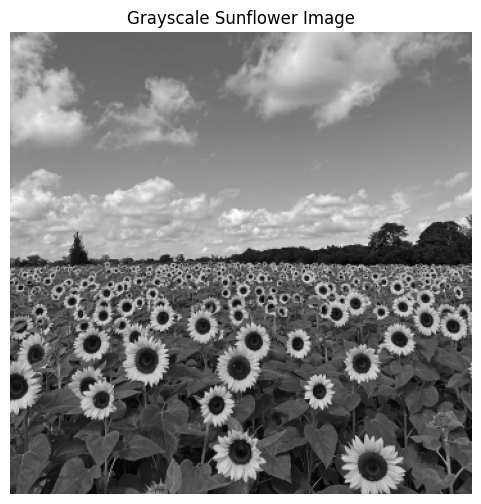

In [6]:
#Question 1
#Imports and Image Reading
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace, maximum_filter

# Read the image (downsampled 1/4th to reduce computation)
img_path = '/content/drive/My Drive/images/the_berry_farms_sunflower_field.jpeg'
im = cv.imread(img_path, cv.IMREAD_REDUCED_COLOR_4)

if im is None:
    raise FileNotFoundError("Image not found! Check the path.")

# Convert to grayscale
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY).astype(np.float32) / 255.0

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Sunflower Image")
plt.axis('off')
plt.show()


In [7]:
#Create Scale Space Using Laplacian of Gaussian

def build_log_scale_space(image, min_radius=1, max_radius=10, n_scales=10):
    radii = np.linspace(min_radius, max_radius, n_scales)
    sigmas = radii / np.sqrt(2)

    H, W = image.shape
    scale_space = np.zeros((n_scales, H, W), dtype=np.float32)

    for i, sigma in enumerate(sigmas):
        # Compute normalized Laplacian of Gaussian
        log_resp = gaussian_laplace(image, sigma=sigma)
        scale_space[i] = (sigma ** 2) * np.abs(log_resp)

    return scale_space, sigmas


In [8]:
#Detect Extrema in Scale-Space

def detect_blobs(scale_space, sigmas, threshold_rel=0.3):
    # Find global maximum for thresholding
    max_val = scale_space.max()
    threshold = threshold_rel * max_val

    # 3D non-maximum suppression
    neighborhood = (3, 9, 9)
    max_filtered = maximum_filter(scale_space, size=neighborhood)
    is_max = (scale_space == max_filtered) & (scale_space >= threshold)

    # Extract blob coordinates (scale index, y, x)
    peaks = np.argwhere(is_max)
    blobs = []
    for s_idx, y, x in peaks:
        sigma = sigmas[s_idx]
        radius = np.sqrt(2) * sigma
        resp = scale_space[s_idx, y, x]
        blobs.append({
            'x': int(x),
            'y': int(y),
            'sigma': float(sigma),
            'radius': float(radius),
            'response': float(resp)
        })

    blobs_sorted = sorted(blobs, key=lambda b: b['response'], reverse=True)
    return blobs_sorted


Total blobs detected: 1169
Largest detected blob: {'x': 323, 'y': 207, 'sigma': 2.1213203435596424, 'radius': 3.0, 'response': 0.3990018665790558}
Sigma range used: [0.71 1.41 2.12 2.83 3.54 4.24 4.95 5.66 6.36 7.07]


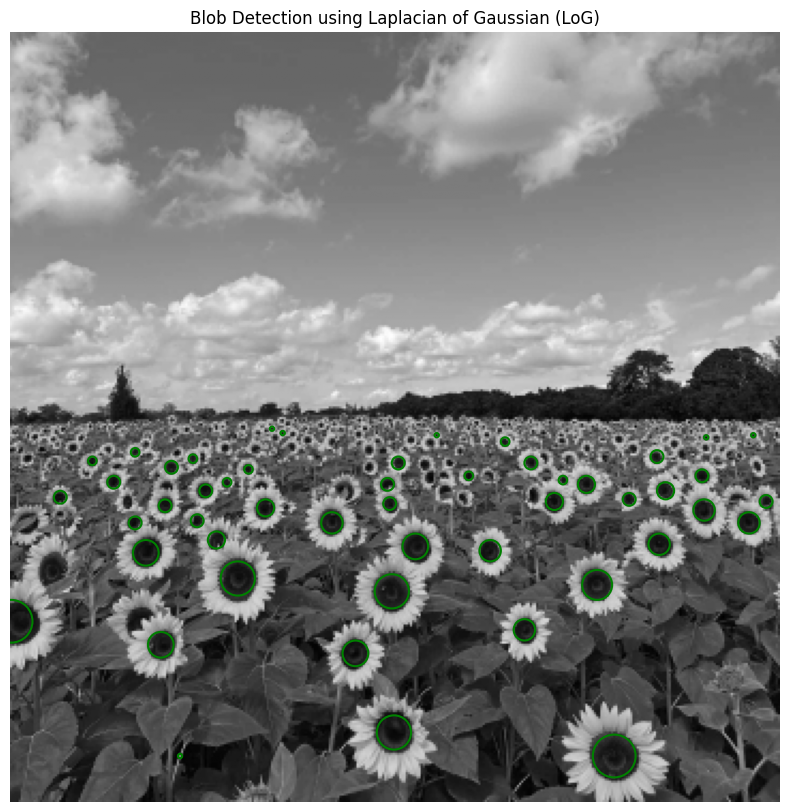

In [9]:
#Run Blob Detection and Display Results

# Build scale-space
scale_space, sigmas = build_log_scale_space(gray, min_radius=1, max_radius=10, n_scales=10)

# Detect blobs
blobs = detect_blobs(scale_space, sigmas, threshold_rel=0.05)

print(f"Total blobs detected: {len(blobs)}")
if blobs:
    print("Largest detected blob:", blobs[0])
print("Sigma range used:", np.round(sigmas, 2))

# Plot image with top blobs
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(gray, cmap='gray')

for b in blobs[:50]:  # visualize top 50 blobs
    circ = plt.Circle((b['x'], b['y']), b['radius'], color='g', fill=False, linewidth=1.5)
    ax.add_patch(circ)

ax.set_title("Blob Detection using Laplacian of Gaussian (LoG)")
plt.axis('off')
plt.show()


#### QUESTION 2 - Fit a line and a circle in noisy points using own RANSAC & refine

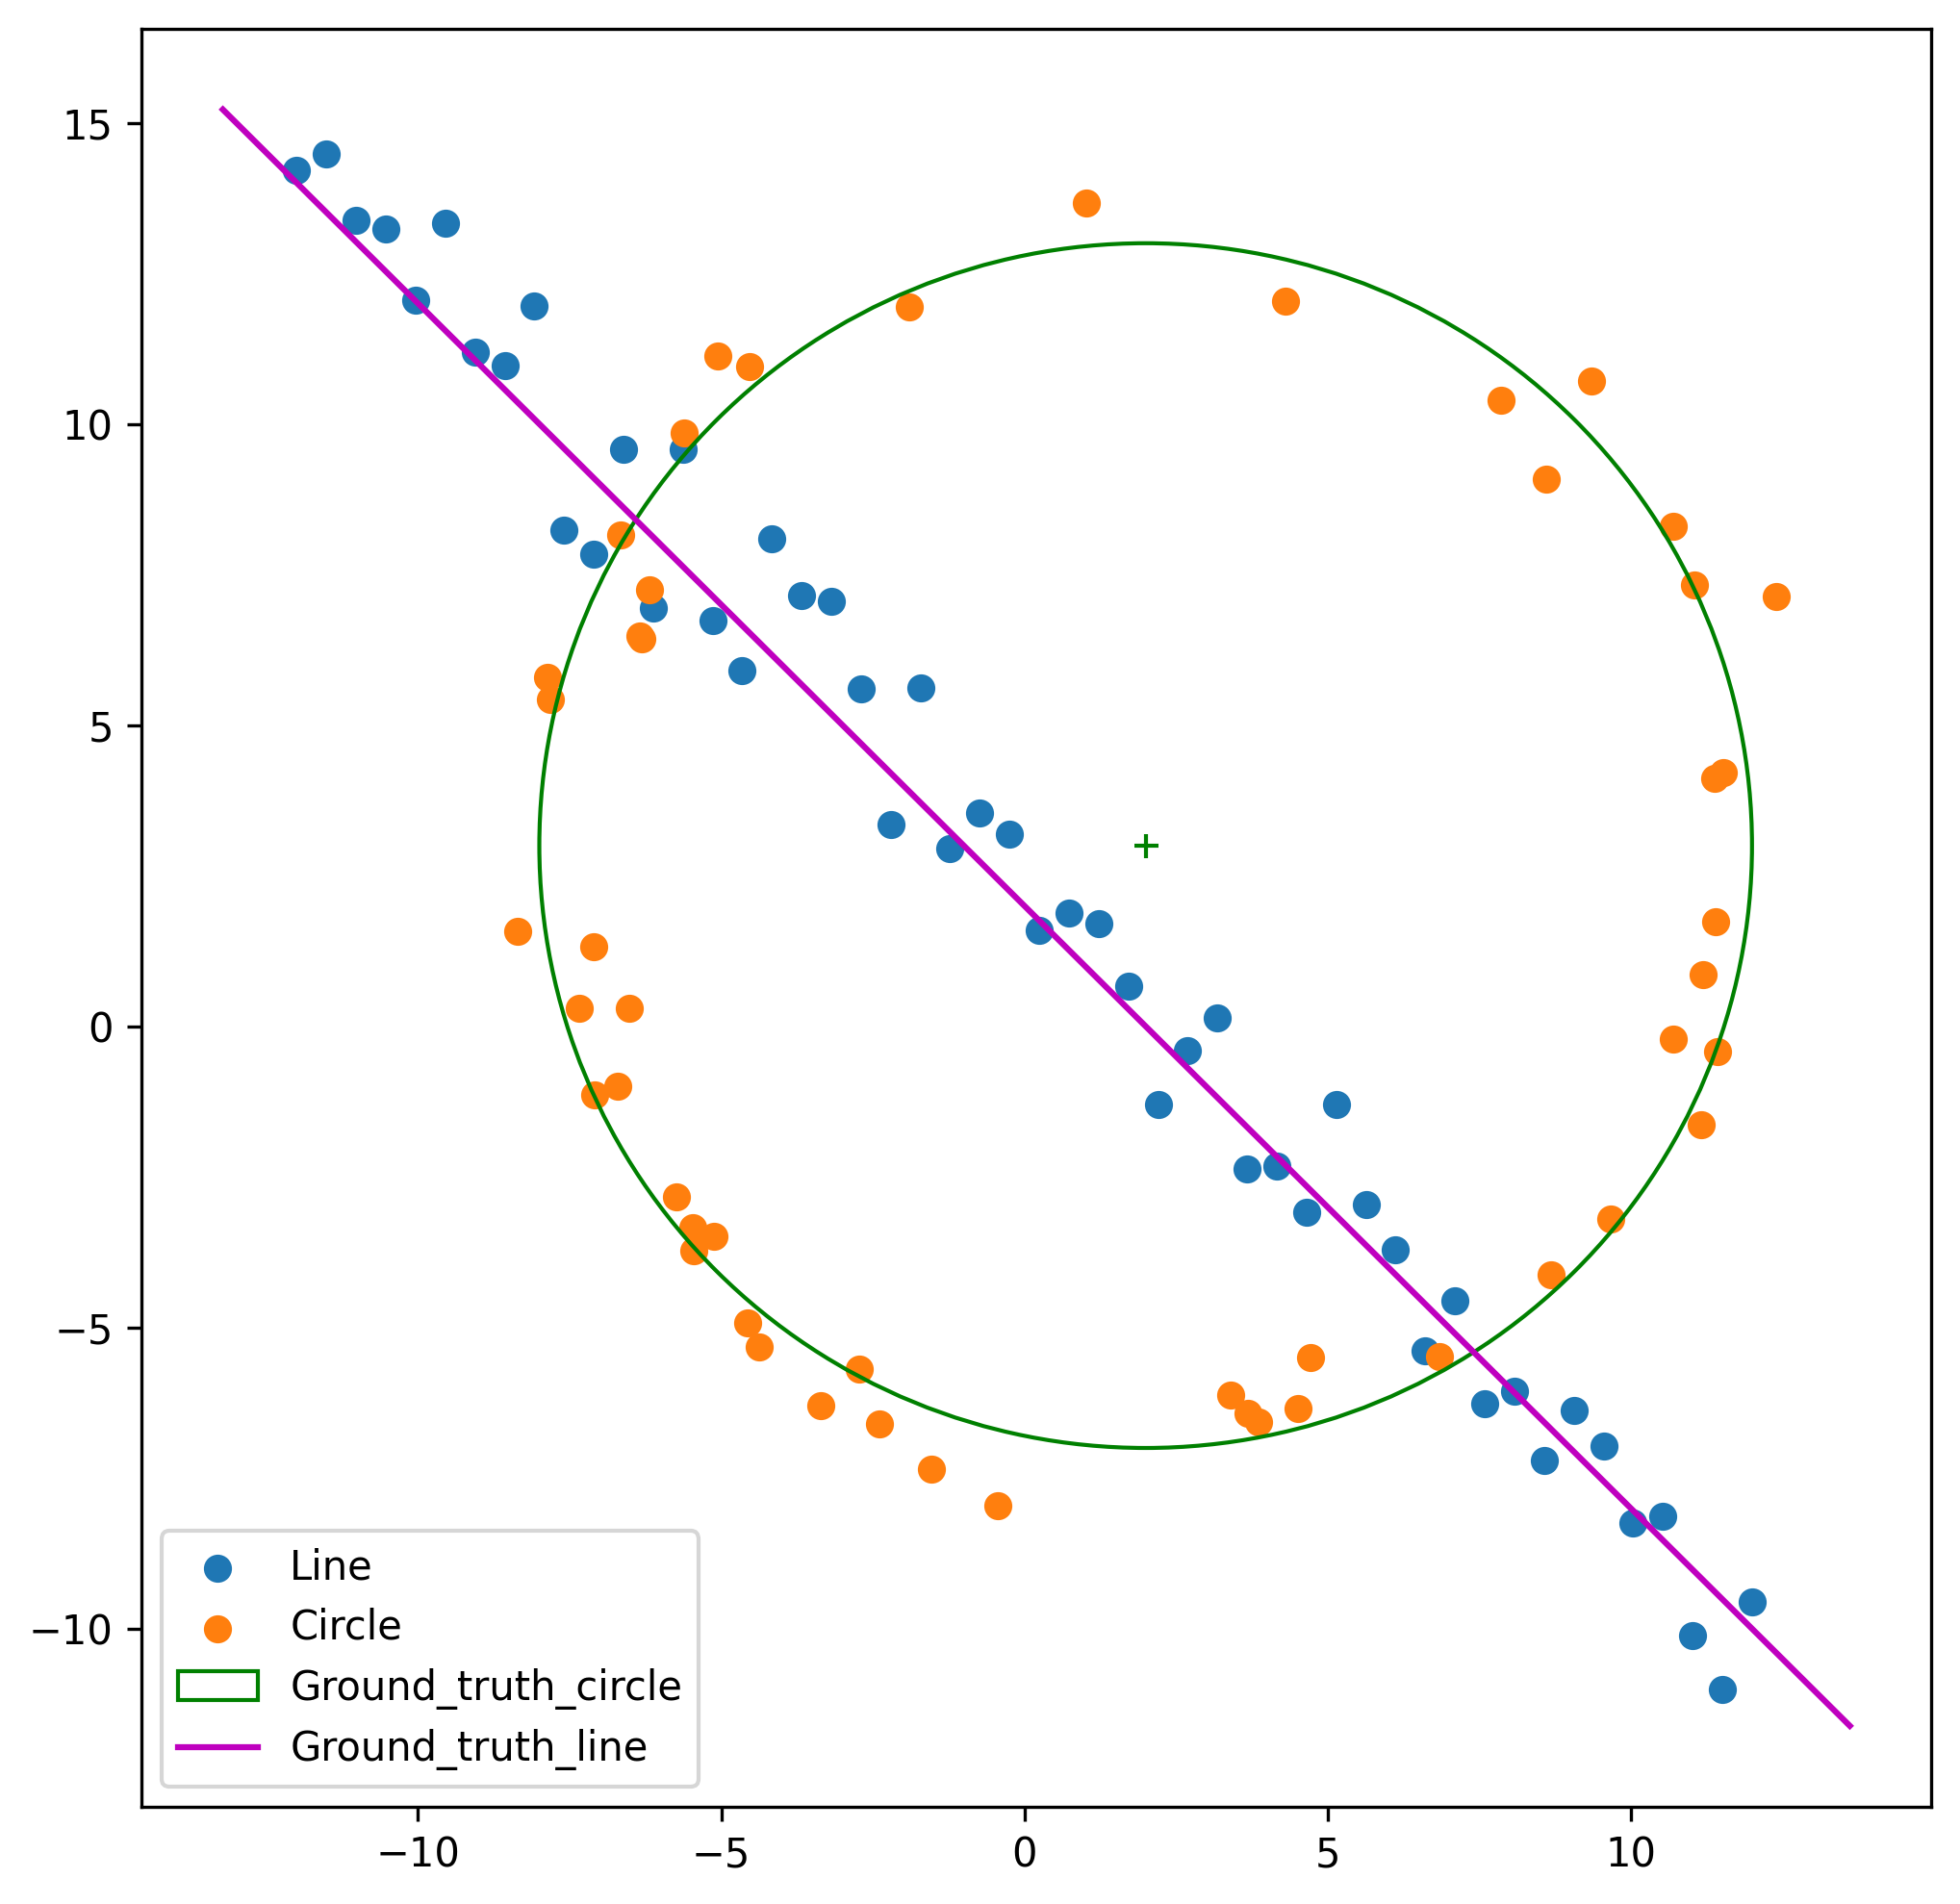

In [12]:
#code snippet in listing 1
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
N = 100
half_n = N//2

r = 10
x0_gt, y0_gt = 2, 3  # Center
s = r/16
t = np.random.uniform(0, 2*np.pi, half_n)
n = s*np.random.randn(half_n)
x, y = x0_gt + (r + n)*np.cos(t), y0_gt + (r + n)*np.sin(t)
X_circ = np.hstack((x.reshape(half_n,1), y.reshape(half_n,1)))
s = 1.
m_gt, b_gt = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s*np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n,1), y.reshape(half_n,1)))
X = np.vstack((X_circ, X_line))  # All points

fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=300)
ax.scatter(X_line[:,0], X_line[:,1], label='Line')
ax.scatter(X_circ[:,0], X_circ[:,1], label='Circle')
circle_gt = plt.Circle((x0_gt,y0_gt), r, color='g', fill=False, label='Ground_truth_circle')
ax.add_patch(circle_gt)
ax.plot((x0_gt), (y0_gt), '+', color='g')
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
plt.plot(x_, y_, color='m', label='Ground_truth_line')
plt.legend()

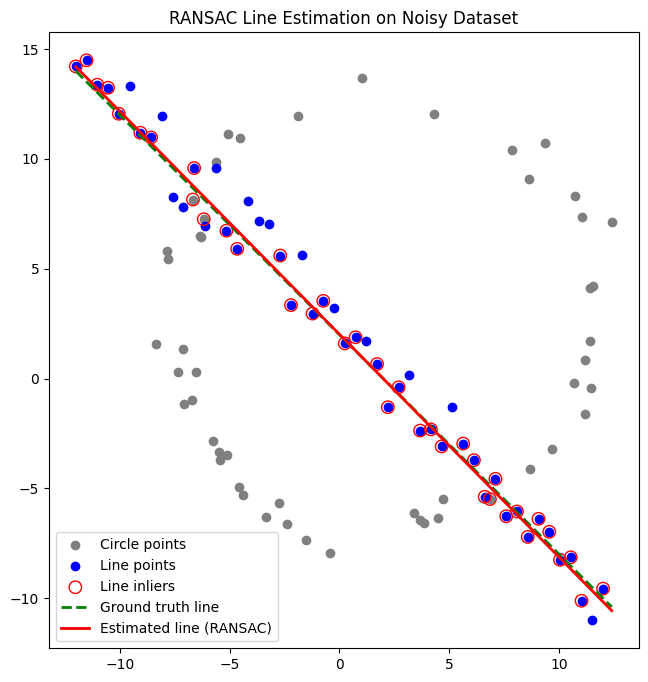

Ground truth line: y = -1x + 2
Estimated line: y = -1.02x + 2.02


In [16]:
#part a
def line_from_two_points(p1, p2):
    """Compute line parameters from two points in the form (a,b,d) -> ax + by = d"""
    if np.allclose(p1, p2):
        return None
    # slope-intercept equivalent in ax + by = d
    a = p2[1] - p1[1]   # Δy
    b = p1[0] - p2[0]   # -Δx
    norm = np.sqrt(a**2 + b**2)
    a, b = a/norm, b/norm
    d = a*p1[0] + b*p1[1]
    return a, b, d

def perp_distances(parameters, X):
    a, b, d = parameters
    return np.abs(a*X[:,0] + b*X[:,1] - d)

# RANSAC parameters
thresh = 0.7      # distance threshold
min_inliers = 40
n_iter = 1500
best_consensus = None
best_params = None

for _ in range(n_iter):
    # Randomly pick 2 points
    idx = np.random.choice(len(X), 2, replace=False)
    p1, p2 = X[idx[0]], X[idx[1]]
    params = line_from_two_points(p1, p2)
    if params is None:
        continue

    # Compute consensus
    dists = perp_distances(params, X)
    consensus = dists < thresh

    # Update best model
    if best_consensus is None or consensus.sum() > best_consensus.sum():
        best_consensus = consensus
        best_params = params


X_inliers = X[best_consensus]
Y_inliers = X_inliers[:,1]
X_mat = np.hstack([X_inliers[:,0].reshape(-1,1), np.ones((len(X_inliers),1))])
B = np.linalg.pinv(X_mat.T @ X_mat) @ X_mat.T @ Y_inliers
m_est, c_est = B[0], B[1]


fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(X_circ[:,0], X_circ[:,1], label='Circle points', color='gray')
ax.scatter(X_line[:,0], X_line[:,1], label='Line points', color='blue')
ax.scatter(X_inliers[:,0], X_inliers[:,1], facecolors='none', edgecolors='r', s=80, label='Line inliers')

# Ground truth line
x_vals = np.array([X[:,0].min(), X[:,0].max()])
y_vals_gt = m_gt*x_vals + b_gt
ax.plot(x_vals, y_vals_gt, 'g--', linewidth=2, label='Ground truth line')

# Estimated line
y_vals_est = m_est*x_vals + c_est
ax.plot(x_vals, y_vals_est, 'r-', linewidth=2, label='Estimated line (RANSAC)')

ax.set_aspect('equal')
ax.legend()
ax.set_title('RANSAC Line Estimation on Noisy Dataset')
plt.show()

print(f"Ground truth line: y = {m_gt}x + {b_gt}")
print(f"Estimated line: y = {m_est:.2f}x + {c_est:.2f}")


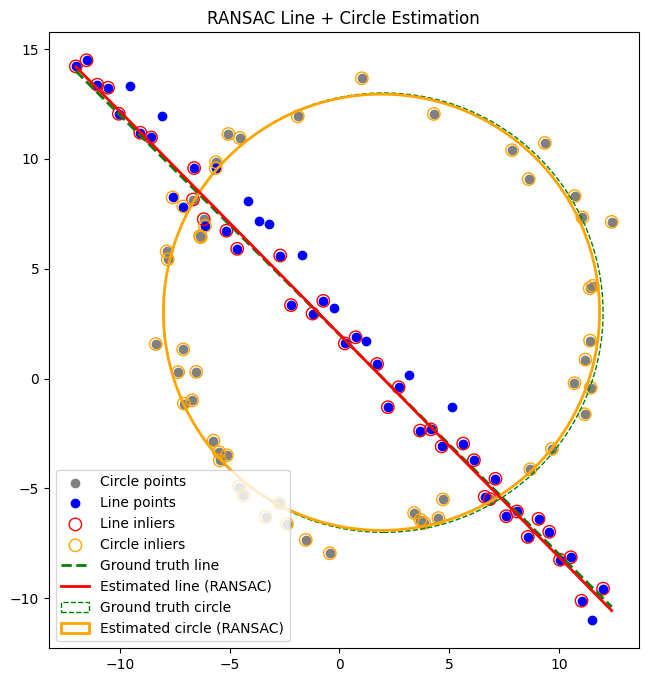

Estimated circle: center = (1.91, 3.02), radius = 9.93
Ground truth circle: center = (2, 3), radius = 10


In [21]:
# part b
# X_inliers is from the previous line RANSAC
X_remaining = X[~best_consensus]  # Points not part of the line

def circle_from_3_points(p1, p2, p3):
    """Return (x0, y0, r) of circle passing through 3 points."""
    A = np.array([
        [p1[0], p1[1], 1],
        [p2[0], p2[1], 1],
        [p3[0], p3[1], 1]
    ])
    B = np.array([
        -(p1[0]**2 + p1[1]**2),
        -(p2[0]**2 + p2[1]**2),
        -(p3[0]**2 + p3[1]**2)
    ])
    try:
        X = np.linalg.solve(A, B)
        x0 = -0.5*X[0]
        y0 = -0.5*X[1]
        r = np.sqrt(x0**2 + y0**2 - X[2])
        return x0, y0, r
    except np.linalg.LinAlgError:
        return None

def radial_distances(circle, points):
    x0, y0, r = circle
    return np.abs(np.sqrt((points[:,0]-x0)**2 + (points[:,1]-y0)**2) - r)


thresh = 1.4       # radial distance tolerance
min_inliers = 40   # minimum points to consider a valid circle
n_iter = 1500

best_circle = None
best_consensus_circle = None

for _ in range(n_iter):
    # Randomly sample 3 points
    if len(X_remaining) < 3:
        break
    idx = np.random.choice(len(X_remaining), 3, replace=False)
    p1, p2, p3 = X_remaining[idx]

    circle = circle_from_3_points(p1, p2, p3)
    if circle is None:
        continue

    # Compute radial distances and consensus
    dists = radial_distances(circle, X_remaining)
    consensus = dists < thresh

    if best_consensus_circle is None or consensus.sum() > best_consensus_circle.sum():
        best_consensus_circle = consensus
        best_circle = circle


X_circle_inliers = X_remaining[best_consensus_circle]

# Linearized circle fit: (x^2 + y^2) = 2*x0*x + 2*y0*y + c
A = np.hstack([2*X_circle_inliers, np.ones((len(X_circle_inliers),1))])
b = (X_circle_inliers[:,0]**2 + X_circle_inliers[:,1]**2)
params = np.linalg.lstsq(A, b, rcond=None)[0]
x0_est, y0_est = params[0], params[1]
r_est = np.sqrt(params[2] + x0_est**2 + y0_est**2)


fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(X_circ[:,0], X_circ[:,1], label='Circle points', color='gray')
ax.scatter(X_line[:,0], X_line[:,1], label='Line points', color='blue')
ax.scatter(X_inliers[:,0], X_inliers[:,1], facecolors='none', edgecolors='r', s=80, label='Line inliers')
ax.scatter(X_circle_inliers[:,0], X_circle_inliers[:,1], facecolors='none', edgecolors='orange', s=80, label='Circle inliers')

# Ground truth line
x_vals = np.array([X[:,0].min(), X[:,0].max()])
y_vals_gt = m_gt*x_vals + b_gt
ax.plot(x_vals, y_vals_gt, 'g--', linewidth=2, label='Ground truth line')

# Estimated line
y_vals_est = m_est*x_vals + c_est
ax.plot(x_vals, y_vals_est, 'r-', linewidth=2, label='Estimated line (RANSAC)')

# Ground truth circle
circle_gt = plt.Circle((x0_gt,y0_gt), r, color='g', fill=False, linestyle='--', label='Ground truth circle')
ax.add_patch(circle_gt)

# Estimated circle
circle_est = plt.Circle((x0_est, y0_est), r_est, color='orange', fill=False, linestyle='-', linewidth=2, label='Estimated circle (RANSAC)')
ax.add_patch(circle_est)

ax.set_aspect('equal')
ax.legend()
ax.set_title('RANSAC Line + Circle Estimation')
plt.show()

print(f"Estimated circle: center = ({x0_est:.2f}, {y0_est:.2f}), radius = {r_est:.2f}")
print(f"Ground truth circle: center = ({x0_gt}, {y0_gt}), radius = {r}")


#### QUESTION 4 — Stitch two graffiti images (SIFT + RANSAC homography + warp)

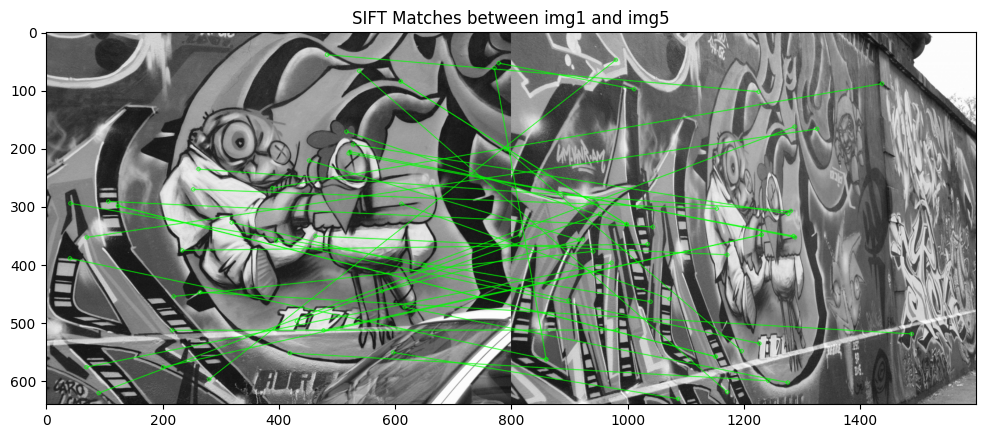

Number of good matches: 40


In [22]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# Load images (grayscale)
img1 = cv.imread('/content/drive/My Drive/images/img1.ppm', cv.IMREAD_GRAYSCALE)
img5 = cv.imread('/content/drive/My Drive/images/img5.ppm', cv.IMREAD_GRAYSCALE)

# Create SIFT detector
sift = cv.SIFT_create()

# Detect keypoints and compute descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp5, des5 = sift.detectAndCompute(img5, None)

# FLANN parameters
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)

# Find matches using kNN
matches = flann.knnMatch(des1, des5, k=2)

# Lowe's ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

# Draw matches
img_matches = cv.drawMatches(img1, kp1, img5, kp5, good_matches, None,
                             matchColor=(0, 255, 0), singlePointColor=(255, 0, 0),
                             flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(12,6))
plt.imshow(img_matches)
plt.title("SIFT Matches between img1 and img5")
plt.show()

print(f"Number of good matches: {len(good_matches)}")



In [23]:
def compute_homography(p1, p2):
    """
    Compute homography H such that p2 ~ H * p1
    p1, p2: Nx2 arrays of corresponding points
    """
    N = p1.shape[0]
    A = []
    for i in range(N):
        x, y = p1[i]
        u, v = p2[i]
        A.append([-x, -y, -1, 0, 0, 0, u*x, u*y, u])
        A.append([0, 0, 0, -x, -y, -1, v*x, v*y, v])
    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3,3)
    return H / H[2,2]  # normalize

# Prepare points from good matches
pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
pts5 = np.float32([kp5[m.trainIdx].pt for m in good_matches])

# RANSAC parameters
thresh = 5.0  # pixel distance
n_iter = 2000
best_H = None
max_inliers = 0
best_inliers_mask = None

np.random.seed(0)
for _ in range(n_iter):
    idx = np.random.choice(len(pts1), 4, replace=False)
    p1_sample = pts1[idx]
    p5_sample = pts5[idx]

    H_candidate = compute_homography(p1_sample, p5_sample)

    # Transform all points
    pts1_h = np.hstack([pts1, np.ones((len(pts1),1))])
    pts1_trans = (H_candidate @ pts1_h.T).T
    pts1_trans = pts1_trans[:, :2] / pts1_trans[:, 2][:, np.newaxis]

    # Compute distances
    dists = np.linalg.norm(pts5 - pts1_trans, axis=1)
    inliers_mask = dists < thresh
    num_inliers = np.sum(inliers_mask)

    if num_inliers > max_inliers:
        max_inliers = num_inliers
        best_H = H_candidate
        best_inliers_mask = inliers_mask

print(f"RANSAC inliers: {max_inliers}/{len(pts1)}")


RANSAC inliers: 7/40


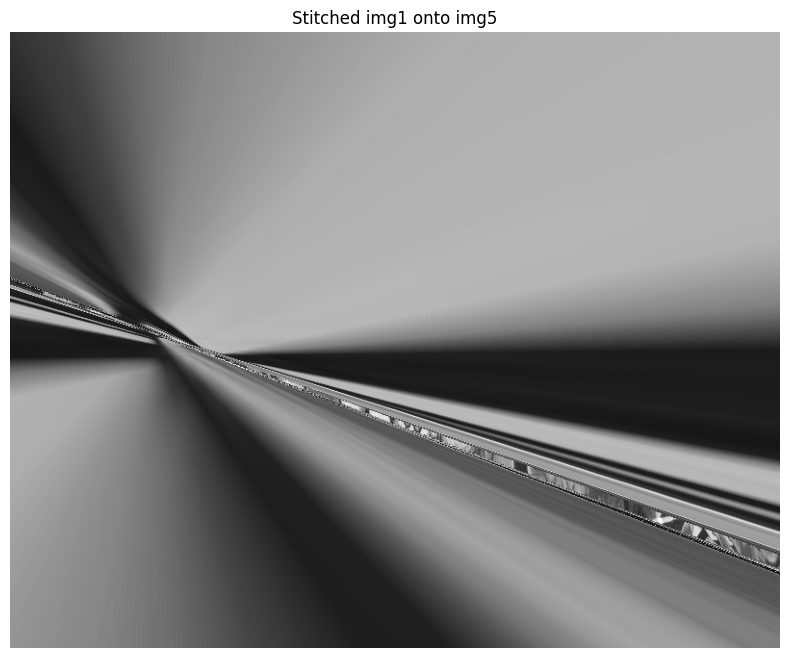

In [24]:
# Warp img1 onto img5 using estimated homography
h5, w5 = img5.shape
h1, w1 = img1.shape

# Compute warped image size
corners = np.array([[0,0],[w1,0],[w1,h1],[0,h1]])
corners_h = np.hstack([corners, np.ones((4,1))])
warped_corners = (best_H @ corners_h.T).T
warped_corners = warped_corners[:, :2] / warped_corners[:,2][:, np.newaxis]

# Determine size of panorama
all_corners = np.vstack([warped_corners, [[0,0],[w5,0],[w5,h5],[0,h5]]])
x_min, y_min = np.floor(all_corners.min(axis=0)).astype(int)
x_max, y_max = np.ceil(all_corners.max(axis=0)).astype(int)

translation = np.array([[1, 0, -x_min],
                        [0, 1, -y_min],
                        [0, 0, 1]])

panorama_size = (x_max - x_min, y_max - y_min)

# Warp img1
img1_warped = cv.warpPerspective(img1, translation @ best_H, panorama_size)

# Place img5 into panorama
panorama = np.zeros((panorama_size[1], panorama_size[0]), dtype=np.uint8)
panorama[-y_min:h5-y_min, -x_min:w5-x_min] = img5

# Combine images
mask_warped = img1_warped > 0
panorama[mask_warped] = img1_warped[mask_warped]

plt.figure(figsize=(12,8))
plt.imshow(panorama, cmap='gray')
plt.title("Stitched img1 onto img5")
plt.axis('off')
plt.show()
